# Projeto de Grafos — Rede de Transações Financeiras e Fraude

**Dataset:** PaySim  
**Stack principal:** Python · pandas · NumPy · DuckDB · NetworkX · Matplotlib  
**Escala de análise:** amostra estrutural de exatamente 1.000 transações

> Este é um projeto exploratório de estudo. O objetivo foi praticar SQL, análise de dados e grafos em um problema realista, registrando também as limitações das decisões tomadas.

## Pergunta de pesquisa

> **A estrutura de uma rede de transações financeiras permite identificar padrões associados às fraudes selecionadas?**

Cada **conta** é representada por um nó e cada **transação** por uma aresta direcionada, da conta de origem para a conta de destino.

O projeto combina atributos transacionais — como tipo, valor e saldos — com métricas de redes, incluindo grau, componentes, PageRank, betweenness, clustering e k-core.

## Estratégia de amostragem

O PaySim completo possui milhões de transações, mas o grafo final é limitado a **1.000 arestas** para manter a análise leve, reproduzível e visualmente explorável.

Uma amostra puramente aleatória pequena tende a destruir recorrências e caminhos importantes. Por isso, a análise utiliza **amostragem orientada à estrutura da rede**, combinando:

1. **25 fraudes distribuídas temporalmente**, garantindo casos suficientes para investigação exploratória;
2. **contas-ponte**, que aparecem tanto como origem quanto como destino;
3. **hubs de destino**, que recebem transações de múltiplas origens;
4. **vizinhanças das contas selecionadas**, preservando pequenas estruturas conectadas;
5. **transações normais distribuídas no tempo**, usadas para completar exatamente 1.000 registros.

## Limitação metodológica essencial

Esta é uma **amostra analítica**, não uma amostra representativa da população. Fraudes e contas estruturalmente interessantes são selecionadas intencionalmente.

Portanto:

- a proporção de fraude da amostra **não estima a prevalência real** no PaySim;
- comparações entre nós associados e não associados a fraude são **exploratórias**;
- os resultados **não demonstram capacidade preditiva** de detecção de fraude;
- a própria estratégia de seleção influencia parte da estrutura observada.

O objetivo é investigar **como métricas de rede podem fornecer contexto estrutural** para transações fraudulentas, e não construir um classificador.

## Glossário rápido

- **Nó:** uma conta.
- **Aresta:** uma transação.
- **Grafo direcionado:** a direção da transação importa.
- **In-degree:** quantidade de conexões que chegam a um nó.
- **Out-degree:** quantidade de conexões que saem de um nó.
- **Centralidade:** medida de importância estrutural de um nó.
- **Componente:** conjunto de nós conectados.
- **Clustering:** tendência à formação de triângulos.
- **Peso:** valor associado a uma aresta; aqui pode representar o valor financeiro movimentado.

## 1. Bibliotecas

As bibliotecas abaixo são utilizadas para carregar e analisar os dados.

Além do NetworkX, utilizamos o **DuckDB** somente na etapa de amostragem. Ele permite consultar o arquivo completo do PaySim sem precisar carregar todas as milhões de linhas simultaneamente na memória.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

import kagglehub
import duckdb

print("NetworkX:", nx.__version__)
print("pandas:", pd.__version__)
print("DuckDB:", duckdb.__version__)

NetworkX: 3.6.1
pandas: 2.3.3
DuckDB: 1.5.5


## 2. Download do PaySim

O dataset completo é obtido diretamente do repositório **Synthetic Financial Datasets For Fraud Detection (PaySim)**.

O arquivo completo é utilizado apenas como fonte para a amostragem. As análises posteriores continuam trabalhando com **1.000 transações**, mantendo o projeto leve o suficiente para visualização e cálculo das métricas.

In [2]:
pasta_paysim = kagglehub.dataset_download("ealaxi/paysim1")

arquivos_csv = []

for raiz, _, arquivos in os.walk(pasta_paysim):
    for nome in arquivos:
        if nome.lower().endswith(".csv"):
            arquivos_csv.append(os.path.join(raiz, nome))

if not arquivos_csv:
    raise FileNotFoundError("Nenhum CSV foi encontrado no dataset PaySim.")

# Caso o dataset possua mais de um CSV, utilizamos o maior.
caminho_paysim = max(arquivos_csv, key=os.path.getsize)

print("Arquivo PaySim utilizado:")
print(caminho_paysim)

Arquivo PaySim utilizado:
C:\Users\torug\.cache\kagglehub\datasets\ealaxi\paysim1\versions\2\PS_20174392719_1491204439457_log.csv


# 3. Como a amostra foi montada

O arquivo completo é grande demais para transformar tudo em um grafo durante esta análise. Por isso, usei uma amostra de 1.000 transações.

Uma tentativa inicial com linhas aleatórias gerou várias contas isoladas. Para manter algumas conexões úteis, a amostra final junta:

- fraudes escolhidas em momentos diferentes;
- contas que recebem e depois enviam dinheiro;
- destinos que recebem muitas transações;
- algumas transações vizinhas dessas contas;
- transações normais para completar as 1.000 linhas.

Essa escolha ajuda a estudar a rede, mas também interfere nos resultados. Portanto, a amostra não representa a proporção real de fraudes do PaySim.

In [3]:
# Valores usados para montar a amostra.
TAMANHO_AMOSTRA = 1000
N_FRAUDES_ALVO = 25
N_CONTAS_PONTE = 15
N_HUBS_DESTINO = 8

MAX_ENTRADAS_POR_PONTE = 10
MAX_SAIDAS_POR_PONTE = 10
MAX_ENTRADAS_POR_HUB = 18
MAX_CONTEXTO_POR_CONTA_FRAUDE = 4

CONTEXTO_MAXIMO = 550
SEED = 42

con = duckdb.connect()
con.execute("SET threads = 1")  # Faz o mesmo sorteio em cada execução.
csv_sql = caminho_paysim.replace("'", "''")


def amostra_temporal(dados, quantidade, seed=SEED, faixas=12):
    """Sorteia linhas em diferentes períodos do PaySim."""

    quantidade = min(quantidade, len(dados))

    if quantidade == 0:
        return dados.iloc[0:0].copy()

    # Se todos os registros forem do mesmo período, basta um sorteio comum.
    if dados["step"].nunique() == 1:
        return dados.sample(quantidade, random_state=seed)

    temporario = dados.copy()
    numero_de_faixas = min(
        faixas,
        temporario["step"].nunique(),
        quantidade
    )

    temporario["_faixa_tempo"] = pd.cut(
        temporario["step"],
        bins=numero_de_faixas,
        duplicates="drop",
        include_lowest=True
    )

    grupos = []
    for _, grupo in temporario.groupby("_faixa_tempo", observed=True):
        grupos.append(grupo)

    quantidade_base = quantidade // len(grupos)
    sobra = quantidade % len(grupos)
    partes = []

    for indice, grupo in enumerate(grupos):
        extra = 1 if indice < sobra else 0
        quantidade_do_grupo = min(quantidade_base + extra, len(grupo))

        if quantidade_do_grupo > 0:
            partes.append(
                grupo.sample(
                    quantidade_do_grupo,
                    random_state=seed + indice
                )
            )

    resultado = pd.concat(partes)

    # Alguns grupos podem ter menos linhas que o necessário.
    # Nesse caso, completamos usando as linhas que ainda não foram escolhidas.
    if len(resultado) < quantidade:
        restantes = temporario.drop(index=resultado.index)
        quanto_falta = quantidade - len(resultado)
        complemento = restantes.sample(
            min(quanto_falta, len(restantes)),
            random_state=seed + 999
        )
        resultado = pd.concat([resultado, complemento])

    resultado = resultado.head(quantidade)
    resultado = resultado.drop(columns="_faixa_tempo")
    return resultado.copy()


# O DuckDB lê somente as fraudes do CSV completo.
fraudes_full = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{csv_sql}', header=true)
    WHERE isFraud = 1
""").df()

amostra_fraude = amostra_temporal(
    fraudes_full,
    quantidade=N_FRAUDES_ALVO,
    seed=SEED,
    faixas=10
)

print("Fraudes disponíveis no PaySim:", len(fraudes_full))
print("Fraudes selecionadas:", len(amostra_fraude))
print("Steps das fraudes selecionadas:", amostra_fraude["step"].nunique())

Fraudes disponíveis no PaySim: 8213
Fraudes selecionadas: 25
Steps das fraudes selecionadas: 25


## 3.1 Identificação direta de contas-ponte

A consulta abaixo varre o PaySim completo e procura contas que realmente apresentam recorrência.

Para evitar que um nó seja considerado “ponte” apenas por receber várias transações, exigimos que ele também tenha atividade de saída.

O ranking prioriza primeiro quem possui mais atividade nos dois papéis e depois quem possui maior atividade total.

In [4]:
contas_ponte = con.execute(f"""
    WITH origens AS (
        SELECT
            nameOrig AS conta,
            COUNT(*) AS qtd_saida
        FROM read_csv_auto('{csv_sql}', header=true)
        GROUP BY nameOrig
        HAVING COUNT(*) >= 2
    ),
    destinos AS (
        SELECT
            nameDest AS conta,
            COUNT(*) AS qtd_entrada
        FROM read_csv_auto('{csv_sql}', header=true)
        WHERE starts_with(nameDest, 'C')
        GROUP BY nameDest
        HAVING COUNT(*) >= 1
    )
    SELECT
        o.conta,
        o.qtd_saida,
        d.qtd_entrada,
        LEAST(o.qtd_saida, d.qtd_entrada) AS atividade_nos_dois_papeis,
        o.qtd_saida + d.qtd_entrada AS atividade_total
    FROM origens o
    INNER JOIN destinos d
        ON o.conta = d.conta
    ORDER BY
        atividade_nos_dois_papeis DESC,
        atividade_total DESC,
        o.qtd_saida DESC
    LIMIT {N_CONTAS_PONTE}
""").df()

display(contas_ponte)

print("Contas-ponte selecionadas:", len(contas_ponte))

,conta,qtd_saida,qtd_entrada,atividade_nos_dois_papeis,atividade_total
0,C1360393616,2,28,2,30
1,C2030913321,2,2,2,4


Contas-ponte selecionadas: 2


## 3.2 Seleção de hubs de destino e montagem do contexto

Também escolhemos alguns destinos recorrentes entre contas de clientes (`C`).

Depois reunimos:

- várias entradas e saídas de cada conta-ponte;
- várias entradas de cada hub;
- transações vizinhas das contas envolvidas nas fraudes selecionadas.

Essa etapa é o que preserva pequenas estruturas conectadas dentro do limite de 1.000 arestas.

In [5]:
hubs_destino = con.execute(f"""
    SELECT
        nameDest AS conta,
        COUNT(*) AS qtd_entrada
    FROM read_csv_auto('{csv_sql}', header=true)
    WHERE starts_with(nameDest, 'C')
    GROUP BY nameDest
    ORDER BY qtd_entrada DESC
    LIMIT {N_HUBS_DESTINO}
""").df()

display(hubs_destino)

ponte_set = set(contas_ponte["conta"])
hub_set = set(hubs_destino["conta"])

contas_fraude = (
    set(amostra_fraude["nameOrig"])
    | set(amostra_fraude["nameDest"])
)

sementes = ponte_set | hub_set | contas_fraude

sementes_sql = ", ".join(
    "'" + str(conta).replace("'", "''") + "'"
    for conta in sorted(sementes)
)

contexto_pool = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{csv_sql}', header=true)
    WHERE
        nameOrig IN ({sementes_sql})
        OR nameDest IN ({sementes_sql})
""").df()

print("Transações candidatas de contexto:", len(contexto_pool))
print("Contas-semente:", len(sementes))

,conta,qtd_entrada
0,C1286084959,113
1,C985934102,109
2,C665576141,105
3,C2083562754,102
4,C248609774,101
5,C1590550415,101
6,C451111351,99
7,C1789550256,99


Transações candidatas de contexto: 1154
Contas-semente: 60


## 3.3 Junção das partes da amostra

Nesta etapa eu junto os grupos escolhidos anteriormente:

1. entradas e saídas das contas-ponte;
2. entradas dos hubs;
3. transações normais próximas às contas envolvidas em fraude;
4. transações normais de fundo até chegar a 1.000 linhas.

Os laços foram mantidos explícitos para deixar visível de onde sai cada parte da amostra.

In [6]:
def chave_transacao(dados):
    """Cria uma identificação simples para cada transação."""

    colunas = ["step", "nameOrig", "nameDest", "amount"]
    chaves = list(dados[colunas].itertuples(index=False, name=None))
    return pd.Series(chaves, index=dados.index)


partes_contexto = []

# Para cada conta-ponte, guardamos algumas entradas e algumas saídas.
for indice, conta in enumerate(contas_ponte["conta"]):
    entradas = contexto_pool[contexto_pool["nameDest"] == conta]
    saidas = contexto_pool[contexto_pool["nameOrig"] == conta]

    if not entradas.empty:
        partes_contexto.append(
            amostra_temporal(
                entradas,
                quantidade=MAX_ENTRADAS_POR_PONTE,
                seed=SEED + 10 * indice,
                faixas=6
            )
        )

    if not saidas.empty:
        partes_contexto.append(
            amostra_temporal(
                saidas,
                quantidade=MAX_SAIDAS_POR_PONTE,
                seed=SEED + 10 * indice + 1,
                faixas=6
            )
        )


# Para cada hub, guardamos algumas das transações que ele recebeu.
for indice, conta in enumerate(hubs_destino["conta"]):
    entradas = contexto_pool[contexto_pool["nameDest"] == conta]

    if not entradas.empty:
        partes_contexto.append(
            amostra_temporal(
                entradas,
                quantidade=MAX_ENTRADAS_POR_HUB,
                seed=SEED + 500 + indice,
                faixas=8
            )
        )


# Também guardamos algumas transações normais das contas ligadas às fraudes.
for indice, conta in enumerate(sorted(contas_fraude)):
    aparece_como_origem = contexto_pool["nameOrig"] == conta
    aparece_como_destino = contexto_pool["nameDest"] == conta
    transacao_normal = contexto_pool["isFraud"] == 0

    vizinhanca = contexto_pool[
        (aparece_como_origem | aparece_como_destino)
        & transacao_normal
    ]

    if not vizinhanca.empty:
        partes_contexto.append(
            amostra_temporal(
                vizinhanca,
                quantidade=MAX_CONTEXTO_POR_CONTA_FRAUDE,
                seed=SEED + 1000 + indice,
                faixas=4
            )
        )


if partes_contexto:
    contexto = pd.concat(partes_contexto, ignore_index=True)
    contexto = contexto.drop_duplicates()
else:
    contexto = contexto_pool.iloc[0:0].copy()

# Remove do contexto as fraudes que já foram selecionadas no começo.
chaves_fraude = set(chave_transacao(amostra_fraude))
contexto_repetido = chave_transacao(contexto).isin(chaves_fraude)
contexto = contexto[~contexto_repetido].head(CONTEXTO_MAXIMO)


# Separamos várias transações normais para preencher o espaço restante.
background_pool = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{csv_sql}', header=true)
    USING SAMPLE 50000 ROWS (reservoir, {SEED})
""").df()

background_pool = background_pool[background_pool["isFraud"] == 0].copy()

chaves_usadas = set(chave_transacao(amostra_fraude))
chaves_usadas.update(chave_transacao(contexto))

background_repetido = chave_transacao(background_pool).isin(chaves_usadas)
background_pool = background_pool[~background_repetido]

quantidade_background = TAMANHO_AMOSTRA - len(amostra_fraude) - len(contexto)
background = amostra_temporal(
    background_pool,
    quantidade=quantidade_background,
    seed=SEED + 2000,
    faixas=20
)


# Junta fraudes, contexto e transações normais.
df = pd.concat(
    [amostra_fraude, contexto, background],
    ignore_index=True
)
df = df.drop_duplicates()


# Este complemento só é usado se alguma duplicata reduzir a amostra.
if len(df) < TAMANHO_AMOSTRA:
    faltam = TAMANHO_AMOSTRA - len(df)
    tamanho_pool = max(5000, faltam * 20)

    complemento_pool = con.execute(f"""
        SELECT *
        FROM read_csv_auto('{csv_sql}', header=true)
        WHERE isFraud = 0
        USING SAMPLE {tamanho_pool} ROWS (reservoir, {SEED + 1})
    """).df()

    chaves_df = set(chave_transacao(df))
    complemento_repetido = chave_transacao(complemento_pool).isin(chaves_df)
    complemento_pool = complemento_pool[~complemento_repetido]

    complemento = amostra_temporal(
        complemento_pool,
        quantidade=faltam,
        seed=SEED + 3000
    )

    df = pd.concat([df, complemento], ignore_index=True)
    df = df.drop_duplicates()


# Embaralha a ordem final, mas mantém o resultado reproduzível.
df = df.head(TAMANHO_AMOSTRA)
df = df.sample(frac=1, random_state=SEED)
df = df.reset_index(drop=True)

assert len(df) == TAMANHO_AMOSTRA, (
    f"A amostra deveria ter {TAMANHO_AMOSTRA} linhas, mas terminou com {len(df)}."
)

ARQUIVO_AMOSTRA = "credits_paysim_amostra_estrutural_1000.csv"
df.to_csv(ARQUIVO_AMOSTRA, index=False)

print("Amostra final:", df.shape)
print("Fraudes:", int(df["isFraud"].sum()))
print("Steps distintos:", df["step"].nunique())
print("Transações de contexto preservadas:", len(contexto))
print("Arquivo:", ARQUIVO_AMOSTRA)

display(df.head())

Amostra final: (1000, 11)
Fraudes: 25
Steps distintos: 318
Transações de contexto preservadas: 230
Arquivo: credits_paysim_amostra_estrutural_1000.csv


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,281,CASH_IN,63316.89,C1653219994,159587.0,222903.89,C204244775,51333.05,0.00,0,0
1,455,PAYMENT,9439.21,C1321043612,141908.3,132469.09,M152469202,0.00,0.00,0,0
2,448,CASH_IN,75188.96,C305681382,2820994.6,2896183.56,C223804656,993350.50,918161.54,0,0
3,370,CASH_OUT,200939.07,C1447901647,0.0,0.00,C1360481544,252340.24,453279.30,0,0
4,155,PAYMENT,23088.13,C371320773,22230.0,0.00,M1289134445,0.00,0.00,0,0


# 4. Validação da amostra estrutural

Antes da análise do grafo, verificamos se a estratégia cumpriu o objetivo definido.

Além da diversidade temporal, são observados explicitamente:

- origens que aparecem mais de uma vez;
- contas presentes nos dois papéis;
- existência de caminhos direcionados com pelo menos duas arestas;
- quantidade de nós com entrada e saída.

Se esses valores forem maiores que zero, significa que a amostra preservou estruturas que uma seleção aleatória pequena provavelmente perderia.

In [7]:
origens = set(df["nameOrig"])
destinos = set(df["nameDest"])
ambos = origens & destinos

orig_repetidas = int(
    df["nameOrig"].value_counts().gt(1).sum()
)

dest_repetidos = int(
    df["nameDest"].value_counts().gt(1).sum()
)

G_validacao = nx.DiGraph()

for _, r in df.iterrows():
    G_validacao.add_edge(
        r["nameOrig"],
        r["nameDest"]
    )

nos_com_entrada_e_saida = [
    n
    for n in G_validacao.nodes()
    if (
        G_validacao.in_degree(n) > 0
        and G_validacao.out_degree(n) > 0
    )
]

caminhos_de_duas_arestas = sum(
    G_validacao.in_degree(n)
    * G_validacao.out_degree(n)
    for n in nos_com_entrada_e_saida
)

diagnostico = pd.DataFrame({
    "Indicador": [
        "Transações",
        "Steps distintos",
        "Contas de origem distintas",
        "Contas de destino distintas",
        "Contas distintas no total",
        "Contas que aparecem como origem e destino",
        "Origens que aparecem mais de uma vez",
        "Destinos que aparecem mais de uma vez",
        "Nós com entrada e saída",
        "Sequências direcionadas potenciais de duas arestas",
        "Fraudes selecionadas",
        "Tipos de transação"
    ],
    "Valor": [
        len(df),
        df["step"].nunique(),
        df["nameOrig"].nunique(),
        df["nameDest"].nunique(),
        len(origens | destinos),
        len(ambos),
        orig_repetidas,
        dest_repetidos,
        len(nos_com_entrada_e_saida),
        caminhos_de_duas_arestas,
        int(df["isFraud"].sum()),
        df["type"].nunique()
    ]
})

display(diagnostico)

display(Markdown(
    f"""
### Interpretação

A amostra final possui **{len(df):,} transações** distribuídas por **{df['step'].nunique()} steps**.

Existem **{orig_repetidas} contas de origem recorrentes** e **{len(ambos)} contas que aparecem tanto recebendo quanto enviando**.

Essas contas produzem **{caminhos_de_duas_arestas} caminhos potenciais de duas arestas**.

Dessa forma, métricas baseadas em caminhos deixam de ser estruturalmente impossíveis. Se a betweenness, a reciprocidade ou o clustering continuarem baixos, o resultado passa a ser uma característica observada da amostra selecionada, e não apenas consequência de usar as primeiras linhas do arquivo.

A amostra contém **{int(df['isFraud'].sum())} fraudes selecionadas intencionalmente**. Portanto, a proporção de fraude desta amostra não representa a taxa populacional do PaySim.
"""
))

,Indicador,Valor
0,Transações,1000
1,Steps distintos,318
2,Contas de origem distintas,998
3,Contas de destino distintas,785
4,Contas distintas no total,1780
5,Contas que aparecem como origem e destino,3
6,Origens que aparecem mais de uma vez,2
7,Destinos que aparecem mais de uma vez,29
8,Nós com entrada e saída,3
9,Sequências direcionadas potenciais de duas are...,25



### Interpretação

A amostra final possui **1,000 transações** distribuídas por **318 steps**.

Existem **2 contas de origem recorrentes** e **3 contas que aparecem tanto recebendo quanto enviando**.

Essas contas produzem **25 caminhos potenciais de duas arestas**.

Dessa forma, métricas baseadas em caminhos deixam de ser estruturalmente impossíveis. Se a betweenness, a reciprocidade ou o clustering continuarem baixos, o resultado passa a ser uma característica observada da amostra selecionada, e não apenas consequência de usar as primeiras linhas do arquivo.

A amostra contém **25 fraudes selecionadas intencionalmente**. Portanto, a proporção de fraude desta amostra não representa a taxa populacional do PaySim.


# 5. Distribuição dos tipos de transação

O gráfico mostra a composição da amostra por tipo de operação.

Como a amostragem foi construída para análise estrutural, essa distribuição não deve ser interpretada automaticamente como a distribuição populacional do PaySim.

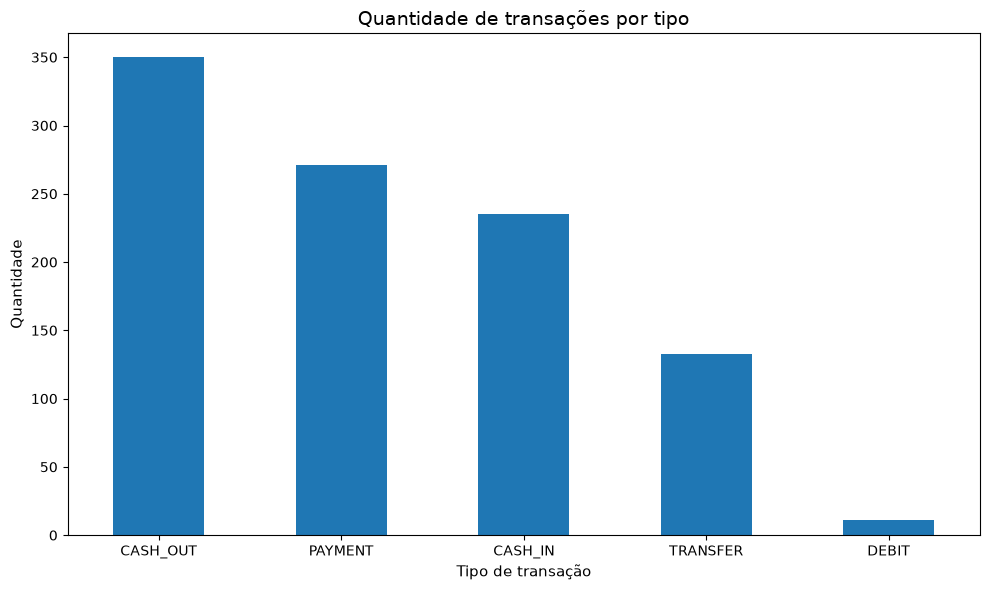

,Quantidade
type,
CASH_OUT,350
PAYMENT,271
CASH_IN,235
TRANSFER,133
DEBIT,11


In [8]:
contagem_tipos = df["type"].value_counts().sort_values(ascending=False)

ax = contagem_tipos.plot(kind="bar")
ax.set_title("Quantidade de transações por tipo")
ax.set_xlabel("Tipo de transação")
ax.set_ylabel("Quantidade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(contagem_tipos.to_frame("Quantidade"))

# 6. Fraudes por tipo de transação

Aqui observamos em quais categorias aparecem as fraudes selecionadas.

A coluna de porcentagem representa a **participação de fraude dentro da nossa amostra**, e não uma estimativa da taxa real do PaySim, porque os casos fraudulentos foram superamostrados propositalmente.

,transacoes,fraudes,valor_mediano,fraudes_na_amostra_%
type,,,,
TRANSFER,133,11,615821.240,8.270677
CASH_OUT,350,14,148873.745,4.000000
CASH_IN,235,0,151252.310,0.000000
DEBIT,11,0,2373.110,0.000000
PAYMENT,271,0,7502.060,0.000000


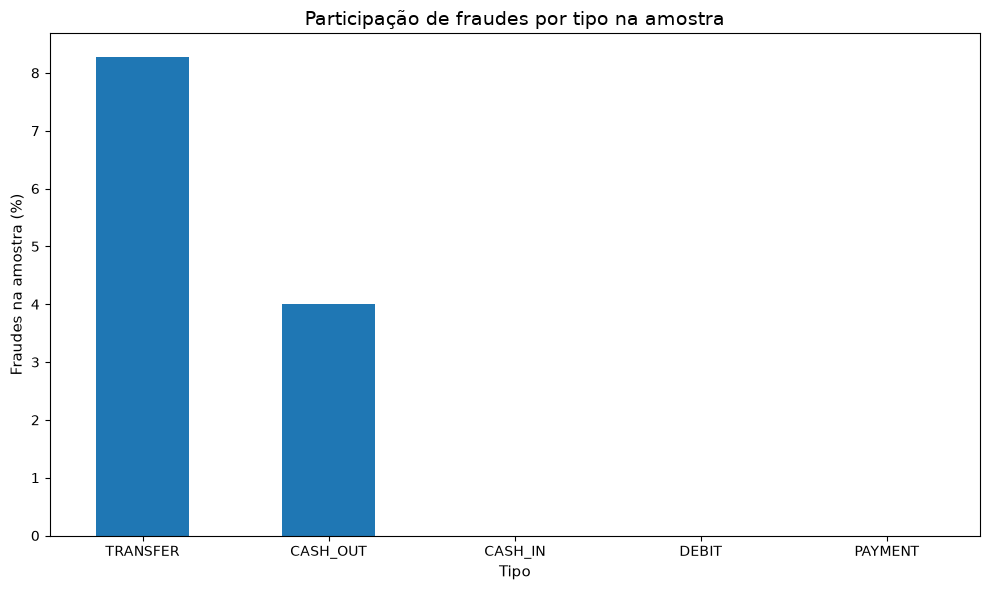

In [9]:
fraude_tipo = (
    df.groupby("type")
      .agg(
          transacoes=("isFraud", "size"),
          fraudes=("isFraud", "sum"),
          valor_mediano=("amount", "median")
      )
)

fraude_tipo["fraudes_na_amostra_%"] = (
    100
    * fraude_tipo["fraudes"]
    / fraude_tipo["transacoes"]
)

display(
    fraude_tipo.sort_values(
        "fraudes_na_amostra_%",
        ascending=False
    )
)

ax = fraude_tipo[
    "fraudes_na_amostra_%"
].sort_values(ascending=False).plot(kind="bar")

ax.set_title("Participação de fraudes por tipo na amostra")
ax.set_xlabel("Tipo")
ax.set_ylabel("Fraudes na amostra (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Valores das transações

Como os valores financeiros podem variar por várias ordens de grandeza, utilizamos `log10(valor + 1)` no eixo horizontal.

A escala logarítmica facilita visualizar transações pequenas e grandes no mesmo gráfico sem alterar a ordem dos valores.

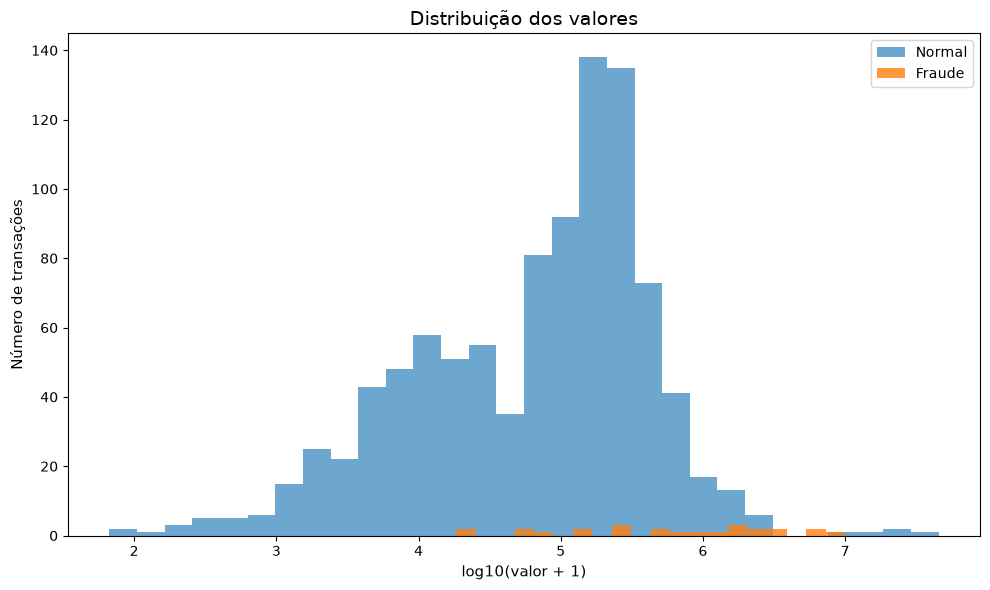

,count,mean,median,min,max
isFraud,,,,,
Normal,975,3.022105e+05,101598.47,66.02,45372634.63
Fraude,25,1.802451e+06,722832.95,18405.16,10000000.00


In [10]:
normais = df.loc[df["isFraud"] == 0, "amount"]
fraudes = df.loc[df["isFraud"] == 1, "amount"]

plt.hist(
    np.log10(normais + 1),
    bins=30,
    alpha=0.65,
    label="Normal"
)

if len(fraudes):
    plt.hist(
        np.log10(fraudes + 1),
        bins=20,
        alpha=0.8,
        label="Fraude"
    )

plt.xlabel("log10(valor + 1)")
plt.ylabel("Número de transações")
plt.title("Distribuição dos valores")
plt.legend()
plt.tight_layout()
plt.show()

resumo_valores = (
    df.groupby("isFraud")["amount"]
      .agg(["count", "mean", "median", "min", "max"])
      .rename(index={0: "Normal", 1: "Fraude"})
)

display(resumo_valores)

# 8. Construção do grafo

Cada conta vira um nó. Cada transação liga a conta de origem à conta de destino.

Vou criar duas versões da mesma rede:

- `G_multi`: mantém cada transação separada;
- `G`: junta as transações repetidas entre o mesmo par de contas.

A primeira guarda os registros individuais. A segunda é mais simples para calcular as métricas de rede.

In [11]:
# Grafo com uma aresta para cada transação.
G_multi = nx.from_pandas_edgelist(
    df,
    source="nameOrig",
    target="nameDest",
    edge_attr=["amount", "type", "isFraud", "step"],
    create_using=nx.MultiDiGraph()
)


# Junta transações que possuem a mesma origem e o mesmo destino.
arestas_agregadas = df.groupby(
    ["nameOrig", "nameDest"],
    as_index=False
).agg(
    qtd_transacoes=("amount", "size"),
    valor_total=("amount", "sum"),
    fraude=("isFraud", "max")
)

# Grafo agregado com uma aresta para cada par de contas.
G = nx.from_pandas_edgelist(
    arestas_agregadas,
    source="nameOrig",
    target="nameDest",
    edge_attr=["qtd_transacoes", "valor_total", "fraude"],
    create_using=nx.DiGraph()
)


# Lista as contas que participaram de pelo menos uma fraude.
linhas_fraude = df[df["isFraud"] == 1]
nos_fraude_amostra = set(linhas_fraude["nameOrig"])
nos_fraude_amostra.update(linhas_fraude["nameDest"])

# Adiciona duas informações simples em cada nó.
for no in G_multi.nodes:
    G_multi.nodes[no]["tipo_conta"] = str(no)[0]
    G_multi.nodes[no]["participou_fraude"] = no in nos_fraude_amostra

for no in G.nodes:
    G.nodes[no]["tipo_conta"] = str(no)[0]
    G.nodes[no]["participou_fraude"] = no in nos_fraude_amostra


print("MultiDiGraph")
print("Nós:", G_multi.number_of_nodes())
print("Transações:", G_multi.number_of_edges())

print("\nDiGraph agregado")
print("Nós:", G.number_of_nodes())
print("Pares conectados:", G.number_of_edges())

pares_repetidos = arestas_agregadas["qtd_transacoes"] > 1
print(
    "\nPares com mais de uma transação:",
    int(pares_repetidos.sum())
)

MultiDiGraph
Nós: 1780
Transações: 1000

DiGraph agregado
Nós: 1780
Pares conectados: 1000

Pares com mais de uma transação: 0


# 9. Métricas globais

### Densidade
Proporção das conexões possíveis que realmente existem.

### Grau médio
Número médio de conexões por nó.

### Reciprocidade
Verifica com que frequência uma relação `A → B` também existe como `B → A`.

### Componentes fracamente conexas
Grupos conectados quando ignoramos temporariamente a direção das arestas.

### Componentes fortemente conexas
Grupos em que todos os nós conseguem alcançar uns aos outros seguindo as direções.

### Clustering
Mede a formação de triângulos.

### k-core
Procura regiões mais densamente conectadas da rede.

### Assortatividade
Indica se nós de graus semelhantes tendem a se conectar.

In [12]:
graus = dict(G.degree())
grau_medio = np.mean(list(graus.values()))

densidade = nx.density(G)
reciprocidade = nx.reciprocity(G)

componentes_fracas = list(
    nx.weakly_connected_components(G)
)

componentes_fortes = list(
    nx.strongly_connected_components(G)
)

maior_fraca = max(
    componentes_fracas,
    key=len
)

maior_forte = max(
    componentes_fortes,
    key=len
)

G_und = G.to_undirected()

clustering_medio = nx.average_clustering(G_und)

core_numbers = nx.core_number(G_und)
max_core = max(core_numbers.values())

assortatividade = nx.degree_assortativity_coefficient(
    G_und
)

metricas = pd.DataFrame({
    "Métrica": [
        "Nós",
        "Arestas agregadas",
        "Densidade",
        "Grau médio",
        "Reciprocidade",
        "Componentes fracamente conexas",
        "Componentes fortemente conexas",
        "Maior componente fraca",
        "Maior componente forte",
        "Clustering médio",
        "Maior k-core",
        "Assortatividade"
    ],
    "Valor": [
        G.number_of_nodes(),
        G.number_of_edges(),
        densidade,
        grau_medio,
        reciprocidade,
        len(componentes_fracas),
        len(componentes_fortes),
        len(maior_fraca),
        len(maior_forte),
        clustering_medio,
        max_core,
        assortatividade
    ]
})

display(metricas)

display(Markdown(
    f"""
### Leitura das métricas

O grafo possui **{G.number_of_nodes():,} nós** e **{G.number_of_edges():,} relações agregadas**.

A maior componente fracamente conexa contém **{len(maior_fraca)} nós**.

A reciprocidade encontrada foi **{reciprocidade:.4f}** e o clustering médio foi **{clustering_medio:.4f}**.

Estes valores são calculados sobre transações distribuídas ao longo de **{df['step'].nunique()} períodos** e incluem contas recorrentes. Estruturas como caminhos, ciclos ou triângulos dependem, portanto, da rede efetivamente selecionada.
"""
))

,Métrica,Valor
0,Nós,1780.000000
1,Arestas agregadas,1000.000000
2,Densidade,0.000316
3,Grau médio,1.123596
4,Reciprocidade,0.000000
5,Componentes fracamente conexas,780.000000
6,Componentes fortemente conexas,1780.000000
7,Maior componente fraca,19.000000
8,Maior componente forte,1.000000
9,Clustering médio,0.000000



### Leitura das métricas

O grafo possui **1,780 nós** e **1,000 relações agregadas**.

A maior componente fracamente conexa contém **19 nós**.

A reciprocidade encontrada foi **0.0000** e o clustering médio foi **0.0000**.

Estes valores são calculados sobre transações distribuídas ao longo de **318 períodos** e incluem contas recorrentes. Estruturas como caminhos, ciclos ou triângulos dependem, portanto, da rede efetivamente selecionada.


# 10. Distribuição de grau

O grau total mede quantas relações um nó possui.

Como o grafo é direcionado, também observamos:

- **in-degree:** quantas contas diferentes enviaram para aquele nó;
- **out-degree:** para quantas contas diferentes aquele nó enviou.

A amostragem preserva deliberadamente algumas contas de origem recorrentes. Assim, o out-degree pode assumir valores maiores que 1 e representar comportamento estrutural dentro da amostra.

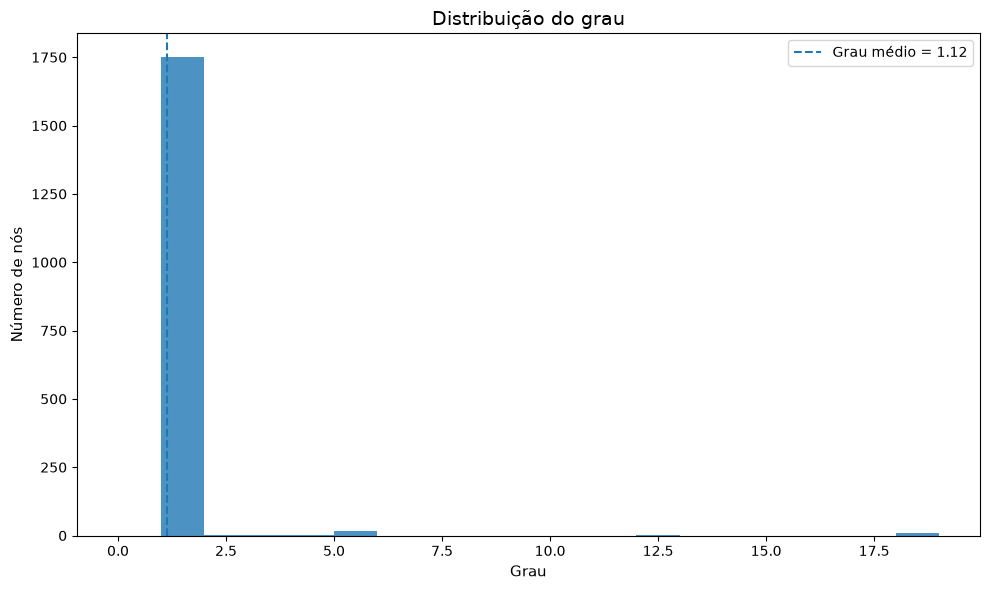

Grau total máximo: 18
In-degree máximo: 18
Out-degree máximo: 2


In [13]:
degree_list = [d for _, d in G.degree()]
in_degree_list = [d for _, d in G.in_degree()]
out_degree_list = [d for _, d in G.out_degree()]

plt.hist(
    degree_list,
    bins=range(0, max(degree_list) + 2),
    alpha=0.8
)

plt.axvline(
    grau_medio,
    linestyle="--",
    label=f"Grau médio = {grau_medio:.2f}"
)

plt.xlabel("Grau")
plt.ylabel("Número de nós")
plt.title("Distribuição do grau")
plt.legend()
plt.tight_layout()
plt.show()

print("Grau total máximo:", max(degree_list))
print("In-degree máximo:", max(in_degree_list))
print("Out-degree máximo:", max(out_degree_list))

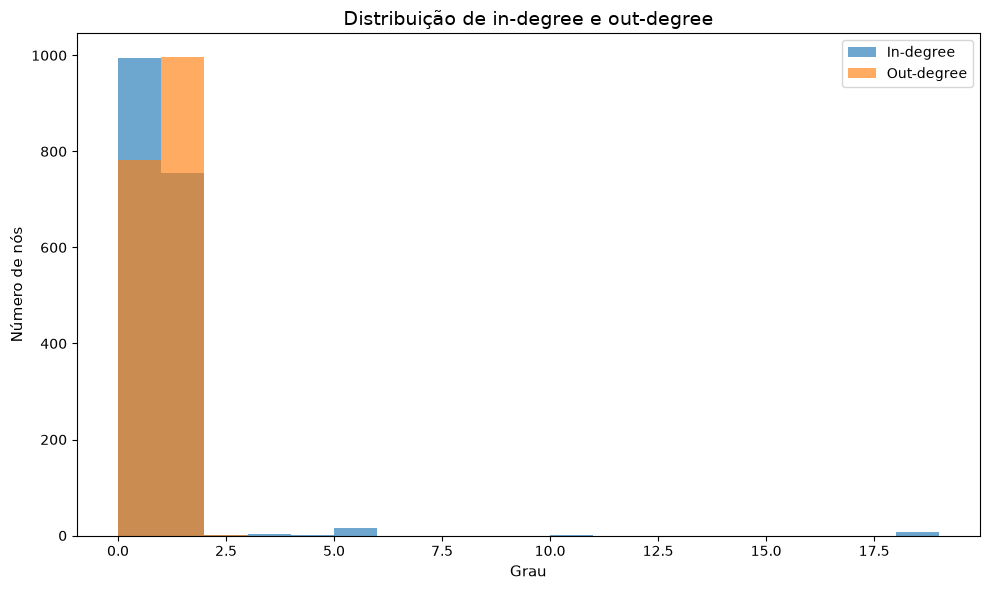

In [14]:
bins = range(
    0,
    max(max(in_degree_list), max(out_degree_list)) + 2
)

plt.hist(
    in_degree_list,
    bins=bins,
    alpha=0.65,
    label="In-degree"
)

plt.hist(
    out_degree_list,
    bins=bins,
    alpha=0.65,
    label="Out-degree"
)

plt.xlabel("Grau")
plt.ylabel("Número de nós")
plt.title("Distribuição de in-degree e out-degree")
plt.legend()
plt.tight_layout()
plt.show()

# 11. Clustering

O coeficiente de agrupamento mede a tendência à formação de triângulos.

Como contas recorrentes e caminhos são preservados deliberadamente, clustering igual ou próximo de zero não é uma consequência automática da forma de amostragem.

Se o valor continuar baixo, a interpretação correta é que **os caminhos preservados não tendem a fechar triângulos**.

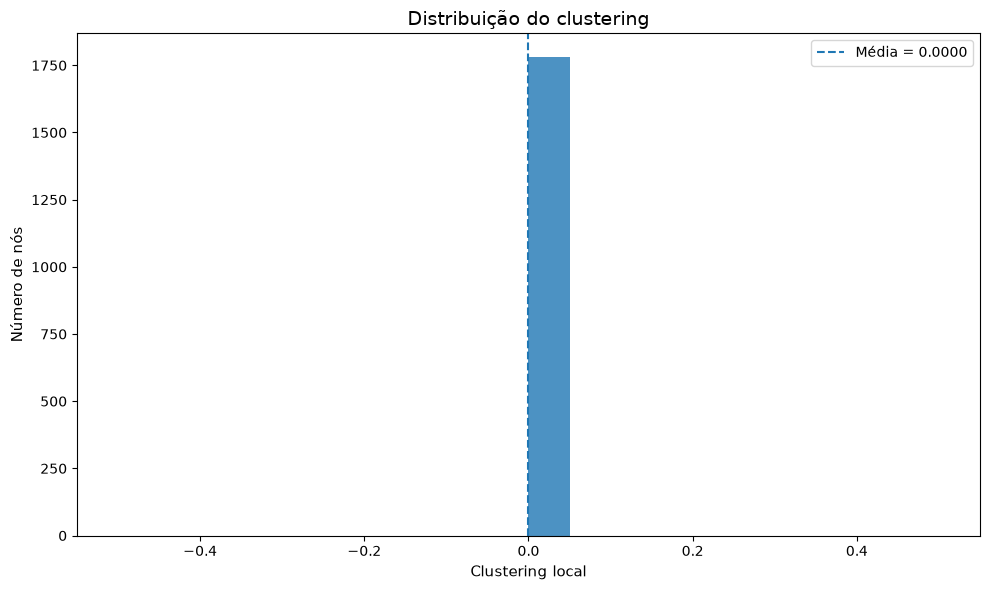

In [15]:
clustering_local = nx.clustering(G_und)

valores_clustering = list(
    clustering_local.values()
)

plt.hist(
    valores_clustering,
    bins=20,
    alpha=0.8
)

plt.axvline(
    clustering_medio,
    linestyle="--",
    label=f"Média = {clustering_medio:.4f}"
)

plt.xlabel("Clustering local")
plt.ylabel("Número de nós")
plt.title("Distribuição do clustering")
plt.legend()
plt.tight_layout()
plt.show()

# 12. Componentes da rede

O gráfico mostra o tamanho das componentes fracamente conexas.

Uma componente maior indica que um conjunto maior de contas está estruturalmente conectado, mesmo quando ignoramos a direção das transações.

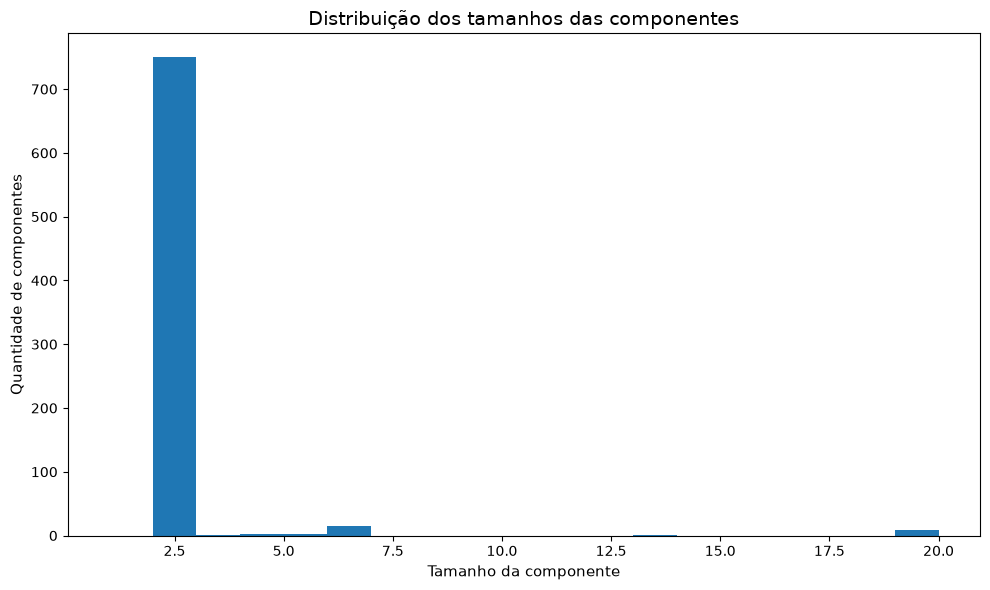

10 maiores componentes:
[19, 19, 19, 19, 19, 19, 19, 19, 13, 6]


In [16]:
tamanhos_componentes = sorted(
    [len(c) for c in componentes_fracas],
    reverse=True
)

plt.hist(
    tamanhos_componentes,
    bins=range(
        1,
        max(tamanhos_componentes) + 2
    )
)

plt.xlabel("Tamanho da componente")
plt.ylabel("Quantidade de componentes")
plt.title("Distribuição dos tamanhos das componentes")
plt.tight_layout()
plt.show()

print("10 maiores componentes:")
print(tamanhos_componentes[:10])

# 13. Centralidades

### In-degree centrality
Destaca contas que recebem conexões de muitas contas.

### Out-degree centrality
Destaca contas que enviam para muitos destinos.

### PageRank
Considera a direção da rede e a importância estrutural das conexões recebidas.

### PageRank ponderado pelo valor
Inclui o valor financeiro das arestas na redistribuição de importância.

### Betweenness centrality
Destaca contas que aparecem como intermediárias nos caminhos mais curtos entre outros nós.

A principal vantagem da amostragem estrutural é permitir a existência de contas com entrada **e** saída. Assim, a betweenness deixa de ser forçada a zero pela construção da amostra.

> **Nota sobre betweenness:** neste projeto, a betweenness é calculada sem pesos. Isso significa que ela mede posição **topológica** nos caminhos da rede. O valor financeiro das transações não é usado como “distância”, pois uma transação de maior valor não representa necessariamente um caminho estruturalmente mais longo ou mais custoso. O valor monetário é analisado separadamente e também entra no PageRank ponderado.


In [17]:
in_cent = nx.in_degree_centrality(G)
out_cent = nx.out_degree_centrality(G)

pagerank = nx.pagerank(
    G,
    alpha=0.85
)

pagerank_valor = nx.pagerank(
    G,
    alpha=0.85,
    weight="valor_total"
)

betweenness = nx.betweenness_centrality(G)

nos_fraude = {
    n
    for n, dados in G.nodes(data=True)
    if dados.get("participou_fraude", False)
}

linhas_cent = []

for n in G.nodes():
    total_enviado = sum(
        d["valor_total"]
        for _, _, d in G.out_edges(
            n,
            data=True
        )
    )

    total_recebido = sum(
        d["valor_total"]
        for _, _, d in G.in_edges(
            n,
            data=True
        )
    )

    linhas_cent.append({
        "no": n,
        "in_degree": G.in_degree(n),
        "out_degree": G.out_degree(n),
        "in_degree_centrality": in_cent[n],
        "out_degree_centrality": out_cent[n],
        "pagerank": pagerank[n],
        "pagerank_valor": pagerank_valor[n],
        "betweenness": betweenness[n],
        "total_enviado": total_enviado,
        "total_recebido": total_recebido,
        "participou_fraude": n in nos_fraude
    })

centralidades = pd.DataFrame(linhas_cent)

display(
    centralidades.nlargest(
        15,
        "in_degree_centrality"
    )
)

,no,in_degree,out_degree,in_degree_centrality,out_degree_centrality,pagerank,pagerank_valor,betweenness,total_enviado,total_recebido,participou_fraude
7,C2083562754,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,10667421.55,False
27,C1789550256,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,64063618.27,False
53,C1590550415,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,7859995.87,False
57,C248609774,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,9309672.08,False
60,C451111351,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,5769084.97,False
83,C1286084959,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,26177857.01,False
185,C665576141,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,27929418.30,False
254,C985934102,18,0,0.010118,0.000000,0.006186,0.006186,0.000000,0.00,8595844.79,False
45,C1360393616,10,2,0.005621,0.001124,0.003605,0.003605,0.000006,76344.91,2435590.83,False
9,C782792546,5,0,0.002811,0.000000,0.001992,0.001992,0.000000,0.00,932337.75,True


# 14. Exploração estrutural dos nós associados às fraudes selecionadas

O objetivo aqui é evitar uma interpretação simplista como:

> “o nó mais central deve ser fraudulento”.

Comparamos, de forma **exploratória**, as métricas dos nós envolvidos nas fraudes selecionadas com as métricas dos demais nós da amostra.

Essa comparação **não é um teste preditivo** e não deve ser interpretada como evidência causal ou populacional, porque a própria amostragem foi condicionada à presença de fraudes e às vizinhanças dessas contas.

O que buscamos é verificar se, **dentro da rede construída**, aparecem diferenças estruturais que mereçam investigação posterior.


In [18]:
comparacao = (
    centralidades
    .groupby("participou_fraude")[
        [
            "in_degree",
            "out_degree",
            "pagerank",
            "pagerank_valor",
            "betweenness",
            "total_enviado",
            "total_recebido"
        ]
    ]
    .agg(["mean", "median", "max"])
)

display(comparacao)

print(
    "Nós envolvidos em fraude:",
    int(centralidades["participou_fraude"].sum())
)

in_degree            out_degree             pagerank  \
                       mean median max       mean median max      mean   
participou_fraude                                                        
False              0.523699    0.0  18   0.563006    1.0   2  0.000550   
True               1.880000    0.5   5   0.520000    1.0   1  0.000985   

                                      pagerank_valor  ...            \
                     median       max           mean  ...       max   
participou_fraude                                     ...             
False              0.000379  0.006186       0.000550  ...  0.006186   
True               0.000540  0.001992       0.000985  ...  0.001992   

                    betweenness                      total_enviado             \
                           mean median           max          mean     median   
participou_fraude                                                               
False              4.385887e-09    0.0  6.322987e-06  170248.46596   5135.485   
True               6.322987e-09    0.0  3.161494e-07  903733.08000  19912.010   

                               total_recebido                         
                           max           mean    median          max  
participou_fraude                                                     
False              45372634.63   1.594639e+05      0.00  64063618.27  
True               10000000.00   1.276878e+06  10709.43  11522396.04  

[2 rows x 21 columns]

Nós envolvidos em fraude: 50


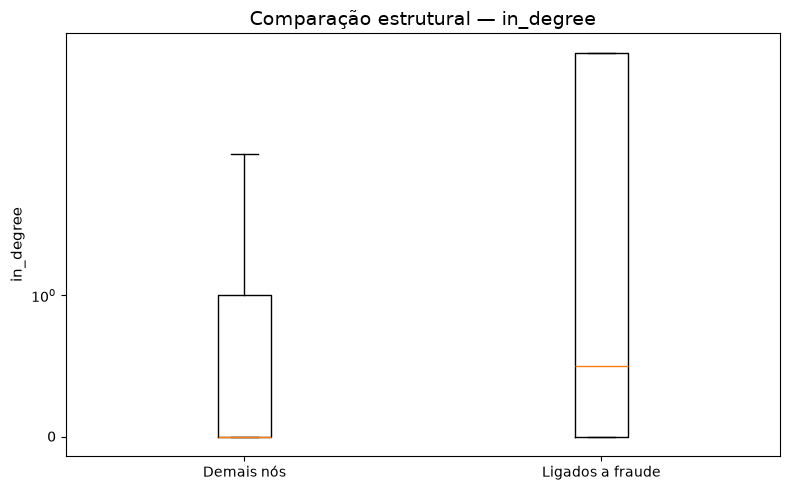

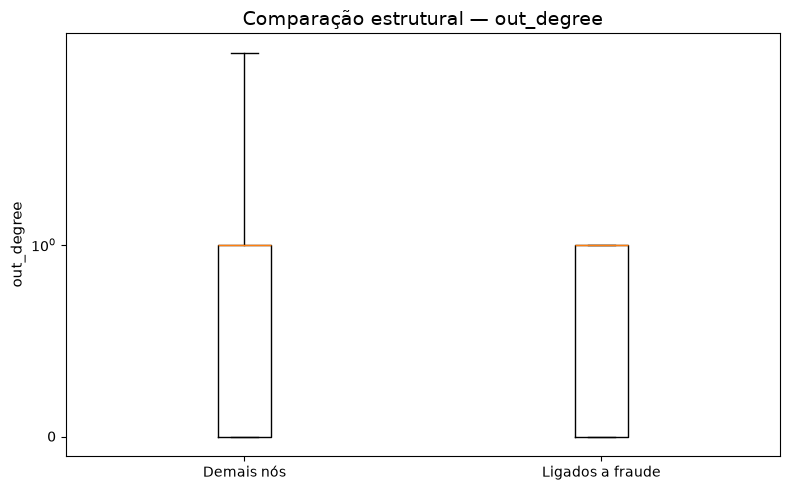

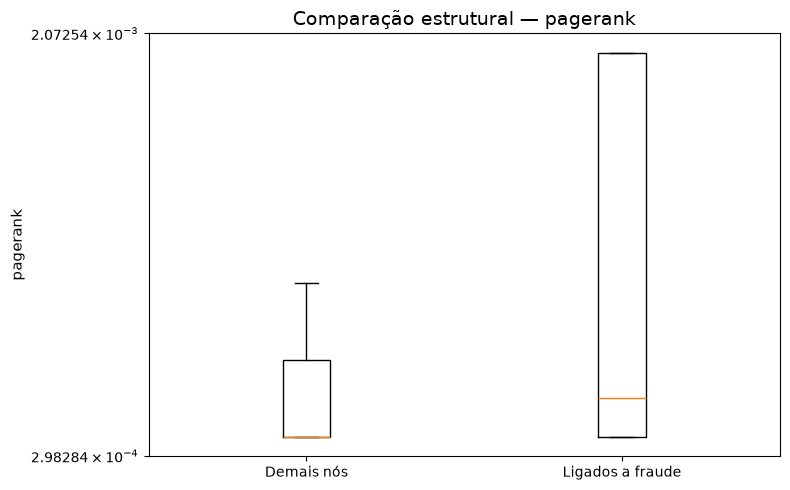

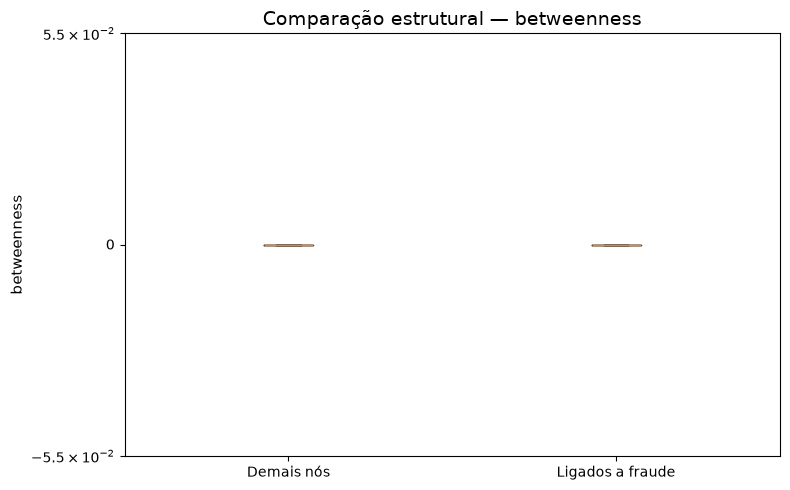

In [19]:
for metrica in [
    "in_degree",
    "out_degree",
    "pagerank",
    "betweenness"
]:
    normal = centralidades.loc[
        ~centralidades["participou_fraude"],
        metrica
    ]

    fraude = centralidades.loc[
        centralidades["participou_fraude"],
        metrica
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [normal, fraude],
        tick_labels=[
            "Demais nós",
            "Ligados a fraude"
        ],
        showfliers=False
    )

    plt.yscale("symlog")
    plt.ylabel(metrica)
    plt.title(
        f"Comparação estrutural — {metrica}"
    )
    plt.tight_layout()
    plt.show()

# 15. Visualização da maior componente

Mostrar todos os nós ao mesmo tempo costuma produzir um grafo ilegível. Por isso visualizamos a maior componente fracamente conexa.

O tamanho dos nós é proporcional ao grau total. Assim, nós maiores possuem mais relações dentro dessa componente.

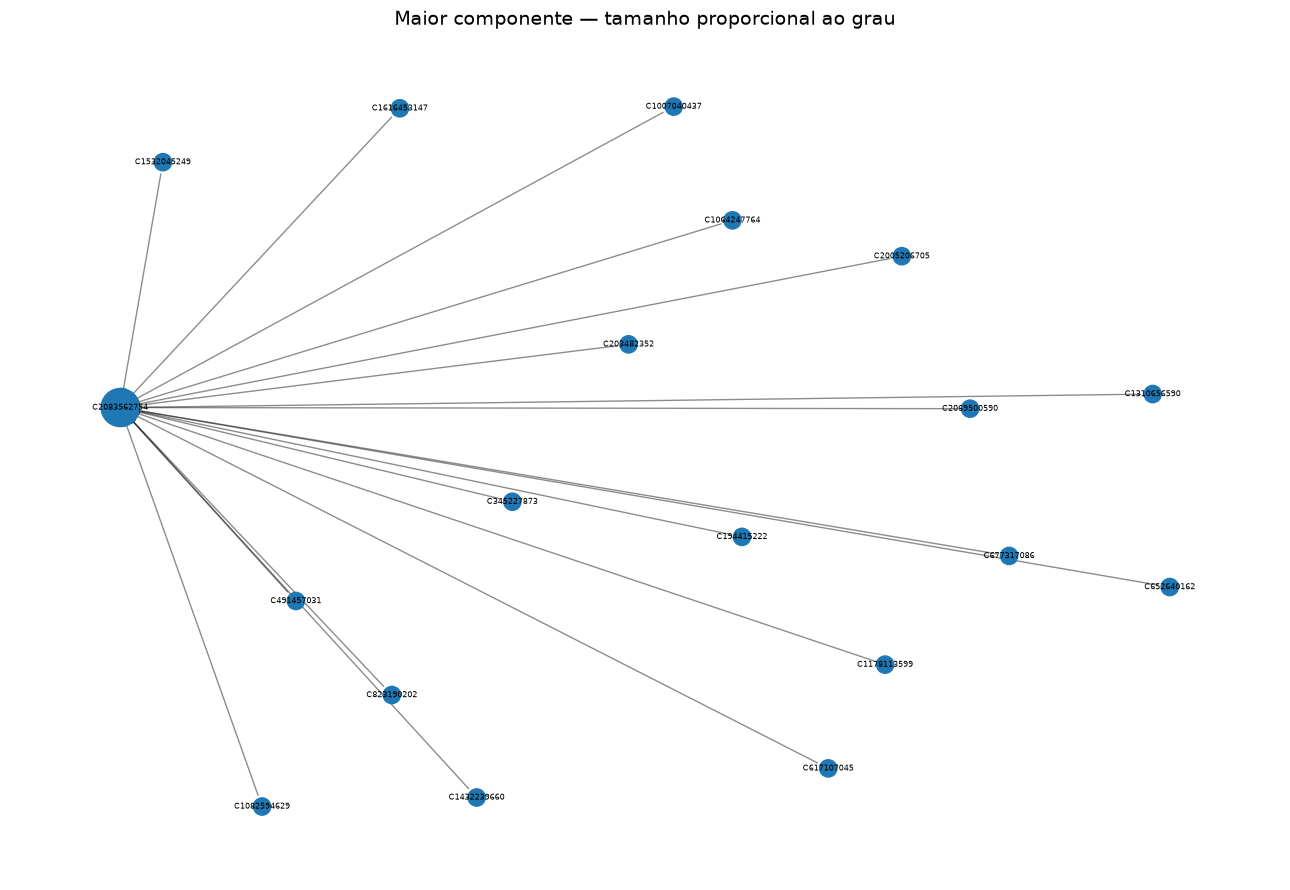

Nós na maior componente: 19
Arestas na maior componente: 18


In [20]:
H_maior = G.subgraph(
    maior_fraca
).copy()

pos = nx.spring_layout(
    H_maior,
    seed=SEED
)

tamanhos = [
    120 + 35 * H_maior.degree(n)
    for n in H_maior.nodes()
]

plt.figure(figsize=(13, 9))

nx.draw_networkx_nodes(
    H_maior,
    pos,
    node_size=tamanhos
)

nx.draw_networkx_edges(
    H_maior,
    pos,
    arrows=True,
    arrowsize=10,
    alpha=0.45
)

# Para componentes grandes, omitimos rótulos para evitar poluição visual.
if H_maior.number_of_nodes() <= 60:
    nx.draw_networkx_labels(
        H_maior,
        pos,
        font_size=6
    )

plt.title(
    "Maior componente — tamanho proporcional ao grau"
)
plt.axis("off")
plt.tight_layout()
plt.show()

print(
    "Nós na maior componente:",
    H_maior.number_of_nodes()
)

print(
    "Arestas na maior componente:",
    H_maior.number_of_edges()
)

# 16. Subgrafo das fraudes

Para analisar diretamente as fraudes, construímos um subgrafo contendo:

- contas participantes de transações fraudulentas;
- vizinhos imediatos dessas contas;
- relações existentes entre esses nós.

As arestas fraudulentas são mostradas com maior espessura.

Com a nova amostragem, o objetivo é verificar se essas transações aparecem isoladas ou inseridas em estruturas maiores da rede.

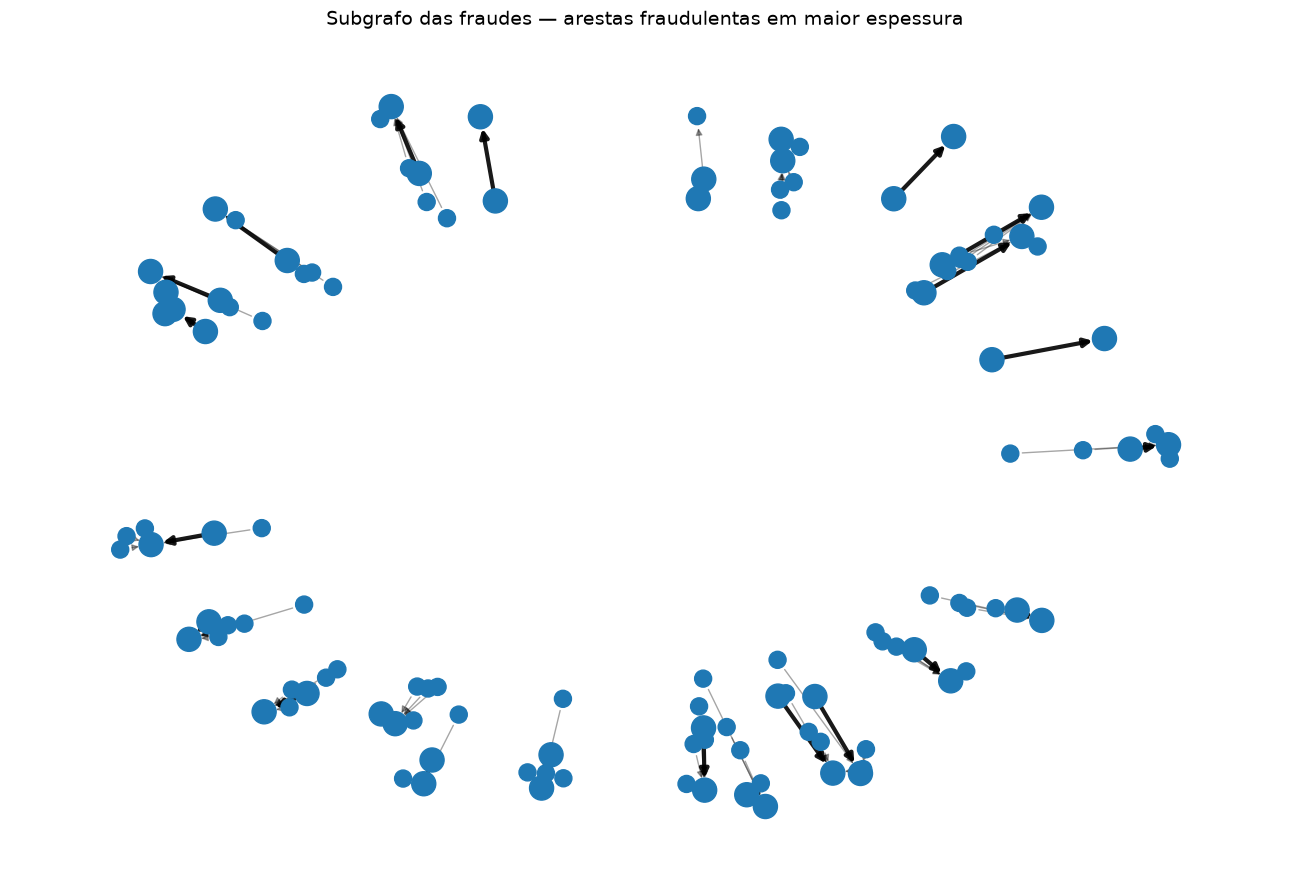

Nós no subgrafo: 120
Arestas no subgrafo: 95
Arestas fraudulentas: 25


In [21]:
arestas_fraude = [
    (u, v)
    for u, v, d in G.edges(data=True)
    if d.get("fraude", 0) == 1
]

nos_contexto_fraude = set(nos_fraude)

for n in list(nos_fraude):
    nos_contexto_fraude.update(
        G.predecessors(n)
    )
    nos_contexto_fraude.update(
        G.successors(n)
    )

H_fraude = G.subgraph(
    nos_contexto_fraude
).copy()

if H_fraude.number_of_nodes() > 0:
    pos_f = nx.spring_layout(
        H_fraude,
        seed=SEED
    )

    normais_contexto = [
        (u, v)
        for u, v in H_fraude.edges()
        if H_fraude[u][v].get(
            "fraude",
            0
        ) == 0
    ]

    fraud_contexto = [
        (u, v)
        for u, v in H_fraude.edges()
        if H_fraude[u][v].get(
            "fraude",
            0
        ) == 1
    ]

    plt.figure(figsize=(13, 9))

    nx.draw_networkx_nodes(
        H_fraude,
        pos_f,
        node_size=[
            300
            if H_fraude.nodes[n].get(
                "participou_fraude",
                False
            )
            else 150
            for n in H_fraude.nodes()
        ]
    )

    nx.draw_networkx_edges(
        H_fraude,
        pos_f,
        edgelist=normais_contexto,
        width=1.0,
        arrows=True,
        arrowsize=10,
        alpha=0.35
    )

    nx.draw_networkx_edges(
        H_fraude,
        pos_f,
        edgelist=fraud_contexto,
        width=3.0,
        arrows=True,
        arrowsize=12,
        alpha=0.9
    )

    if H_fraude.number_of_nodes() <= 70:
        nx.draw_networkx_labels(
            H_fraude,
            pos_f,
            font_size=6
        )

    plt.title(
        "Subgrafo das fraudes — arestas fraudulentas em maior espessura"
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

print(
    "Nós no subgrafo:",
    H_fraude.number_of_nodes()
)

print(
    "Arestas no subgrafo:",
    H_fraude.number_of_edges()
)

print(
    "Arestas fraudulentas:",
    len(arestas_fraude)
)

# 17. Fluxo financeiro

Além da topologia, calculamos quanto cada conta enviou e recebeu.

Cada ponto do gráfico é uma conta:

- eixo horizontal: total enviado;
- eixo vertical: total recebido.

A escala logarítmica permite visualizar valores financeiros muito diferentes no mesmo gráfico.

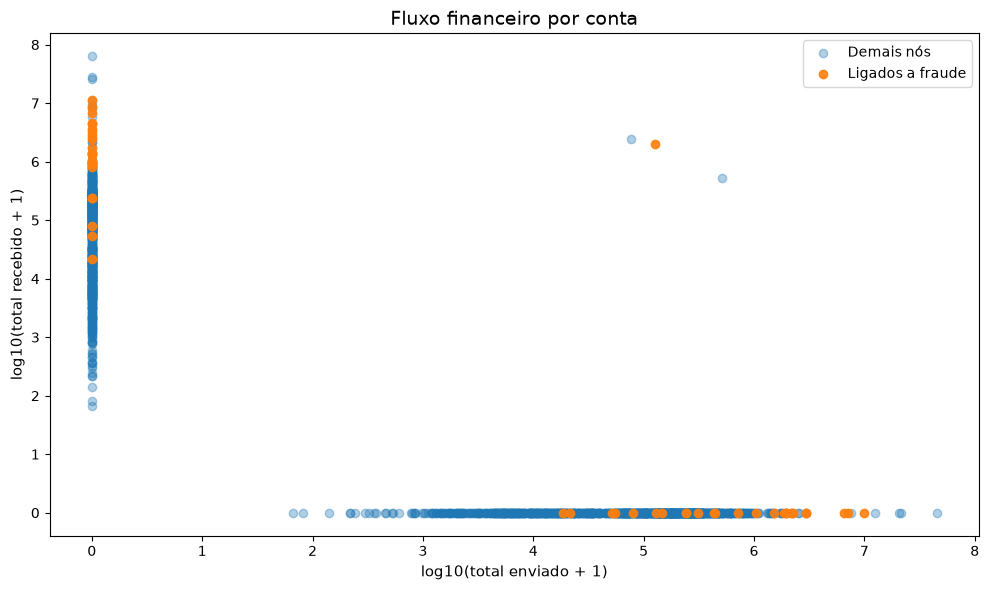

In [22]:
normal_nos = centralidades[
    ~centralidades["participou_fraude"]
]

fraude_nos = centralidades[
    centralidades["participou_fraude"]
]

plt.scatter(
    np.log10(
        normal_nos["total_enviado"] + 1
    ),
    np.log10(
        normal_nos["total_recebido"] + 1
    ),
    alpha=0.35,
    label="Demais nós"
)

plt.scatter(
    np.log10(
        fraude_nos["total_enviado"] + 1
    ),
    np.log10(
        fraude_nos["total_recebido"] + 1
    ),
    alpha=0.9,
    label="Ligados a fraude"
)

plt.xlabel(
    "log10(total enviado + 1)"
)

plt.ylabel(
    "log10(total recebido + 1)"
)

plt.title(
    "Fluxo financeiro por conta"
)

plt.legend()
plt.tight_layout()
plt.show()

# 18. Saldos antes e depois das transações

Esta etapa utiliza atributos das arestas para complementar as métricas de grafo.

Um exemplo é verificar com que frequência a conta de origem termina com saldo zero depois da operação.

Como as fraudes foram superamostradas, comparamos **padrões dentro dos grupos**, e não a frequência populacional de fraude.

In [23]:
df_saldos = df.copy()

df_saldos["variacao_origem"] = (
    df_saldos["oldbalanceOrg"]
    - df_saldos["newbalanceOrig"]
)

df_saldos["variacao_destino"] = (
    df_saldos["newbalanceDest"]
    - df_saldos["oldbalanceDest"]
)

df_saldos["origem_zerou"] = (
    (df_saldos["oldbalanceOrg"] > 0)
    & (df_saldos["newbalanceOrig"] == 0)
)

resumo_saldos = (
    df_saldos
    .groupby("isFraud")
    .agg(
        transacoes=("isFraud", "size"),
        valor_mediano=("amount", "median"),
        proporcao_origem_zerou=(
            "origem_zerou",
            "mean"
        ),
        variacao_origem_mediana=(
            "variacao_origem",
            "median"
        ),
        variacao_destino_mediana=(
            "variacao_destino",
            "median"
        )
    )
    .rename(
        index={
            0: "Normal",
            1: "Fraude"
        }
    )
)

resumo_saldos[
    "proporcao_origem_zerou"
] *= 100

display(resumo_saldos)

,transacoes,valor_mediano,proporcao_origem_zerou,variacao_origem_mediana,variacao_destino_mediana
isFraud,,,,,
Normal,975,101598.47,24.0,0.00,0.00
Fraude,25,722832.95,100.0,722832.95,51416.08


# 19. Correlação entre métricas

A matriz de Spearman verifica se diferentes métricas estão produzindo rankings semelhantes.

Valores próximos de 1 indicam relação monotônica positiva; próximos de -1 indicam relação inversa; próximos de zero indicam pouca relação monotônica.

Essa análise ajuda a identificar métricas redundantes.

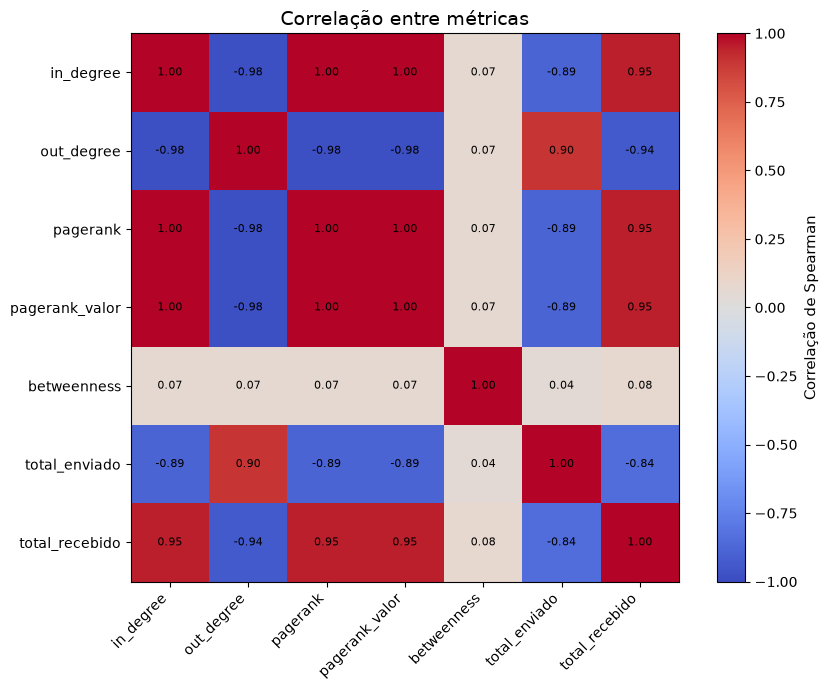

In [24]:
cols_corr = [
    "in_degree",
    "out_degree",
    "pagerank",
    "pagerank_valor",
    "betweenness",
    "total_enviado",
    "total_recebido"
]

corr = centralidades[
    cols_corr
].corr(method="spearman")

fig, ax = plt.subplots(
    figsize=(9, 7)
)

im = ax.imshow(
    corr.values,
    vmin=-1,
    vmax=1,
    cmap=plt.cm.coolwarm
)

ax.set_xticks(
    range(len(cols_corr))
)

ax.set_yticks(
    range(len(cols_corr))
)

ax.set_xticklabels(
    cols_corr,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    cols_corr
)

for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        valor = corr.iloc[i, j]

        texto = (
            "—"
            if pd.isna(valor)
            else f"{valor:.2f}"
        )

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(
    im,
    label="Correlação de Spearman"
)

plt.title(
    "Correlação entre métricas"
)

plt.tight_layout()
plt.show()

# 20. Exportação para Gephi

O grafo agregado é exportado em formato `.gexf`.

Isso permite abrir exatamente a mesma rede no Gephi para exploração visual complementar, sem alterar os cálculos realizados no NetworkX.

In [25]:
ARQUIVO_GEPHI = "paysim_amostra_1000.gexf"

nx.write_gexf(
    G,
    ARQUIVO_GEPHI
)

print(
    "Grafo exportado para:",
    ARQUIVO_GEPHI
)

Grafo exportado para: paysim_amostra_1000.gexf


# 21. Conclusão

A principal contribuição metodológica deste projeto é mostrar que, ao trabalhar com uma rede muito maior do que a escala disponível para exploração, **a estratégia de amostragem passa a fazer parte do problema analítico**.

Em vez de utilizar apenas as primeiras linhas do PaySim ou uma seleção puramente aleatória, a amostra preserva deliberadamente:

- múltiplos períodos temporais;
- fraudes suficientes para investigação exploratória;
- contas-ponte com entradas e saídas;
- hubs de destino;
- vizinhanças locais;
- transações normais de fundo.

Isso torna possíveis análises de grau, componentes, centralidades, caminhos e fluxo financeiro que poderiam desaparecer em uma amostra pequena sem estrutura.

A interpretação dos resultados deve manter duas ideias separadas:

1. **centralidade não significa fraude** — um nó estruturalmente importante pode ser completamente normal;
2. **estrutura de rede pode fornecer contexto útil** — especialmente quando combinada com tipo de transação, valor, direção do fluxo e comportamento dos saldos.

## Limitações

A rede analisada contém apenas 1.000 transações de um dataset com milhões de operações. Além disso, fraudes e determinadas estruturas foram selecionadas intencionalmente. Por isso:

- os resultados não estimam características populacionais do PaySim;
- diferenças entre grupos devem ser lidas como exploração da amostra;
- o projeto não avalia desempenho de classificação ou detecção automática de fraude.

## Resultados empíricos desta execução

- A rede agregada reuniu **1.780 nós** e **1.000 arestas**, com densidade **0,000316** e maior componente fraca de **19 nós**.
- Os **50 nós** associados às 25 fraudes selecionadas apresentaram in-degree médio **1,88**, ante **0,52** nos demais nós, e PageRank médio **0,000985**, ante **0,000550**.
- Nas transações fraudulentas, o valor mediano foi **722.832,95**, ante **101.598,47** nas transações normais da amostra; a origem terminou com saldo zero em **100%** das fraudes selecionadas, contra **24,00%** das demais transações.
- Reciprocidade e clustering ficaram em **0**, e o maior k-core foi **1**, indicando uma rede extremamente esparsa e pouco coesa.

Esses achados respondem à pergunta de pesquisa apenas de forma exploratória: existem diferenças estruturais e transacionais observáveis na amostra, mas a seleção intencional impede inferência populacional ou alegações preditivas.

# Síntese metodológica

**Problema:** uma amostra pequena e ingênua destruía justamente as recorrências e caminhos necessários para analisar a rede.

**Decisão principal:** construir uma amostra estrutural de 1.000 transações usando o PaySim completo como fonte, preservando contas-ponte, hubs, vizinhanças de fraude e diversidade temporal.

**Ferramentas:** DuckDB para consultar o dataset completo sem carregar tudo em memória; pandas/NumPy para manipulação; NetworkX para modelagem e métricas de grafos; Matplotlib para visualização.

**Aprendizado central:** a forma de amostrar os dados altera diretamente as propriedades estruturais observáveis do grafo.

**Limite da conclusão:** o projeto é exploratório e não demonstra capacidade preditiva de detecção de fraude.


# 22. Resumo executivo da execução

Esta última célula reúne automaticamente os principais indicadores calculados ao longo do notebook.

In [26]:
display(Markdown(
    f"""
## Principais números desta execução

- **Transações:** {len(df):,}
- **Steps representados:** {df['step'].nunique()}
- **Fraudes selecionadas:** {int(df['isFraud'].sum())}
- **Nós:** {G.number_of_nodes():,}
- **Arestas agregadas:** {G.number_of_edges():,}
- **Contas que aparecem como origem e destino:** {len(set(df['nameOrig']) & set(df['nameDest']))}
- **Origens recorrentes:** {int(df['nameOrig'].value_counts().gt(1).sum())}
- **Nós com entrada e saída:** {sum(1 for n in G if G.in_degree(n) > 0 and G.out_degree(n) > 0)}
- **Grau médio:** {grau_medio:.3f}
- **In-degree máximo:** {max(in_degree_list)}
- **Out-degree máximo:** {max(out_degree_list)}
- **Betweenness máxima:** {max(betweenness.values()):.6f}
- **Densidade:** {densidade:.6f}
- **Reciprocidade:** {reciprocidade:.6f}
- **Clustering médio:** {clustering_medio:.6f}
- **Componentes fracamente conexas:** {len(componentes_fracas)}
- **Maior componente:** {len(maior_fraca)} nós
- **Maior k-core:** {max_core}

Resumo gerado diretamente a partir dos objetos calculados nesta execução.
"""
))


## Principais números desta execução

- **Transações:** 1,000
- **Steps representados:** 318
- **Fraudes selecionadas:** 25
- **Nós:** 1,780
- **Arestas agregadas:** 1,000
- **Contas que aparecem como origem e destino:** 3
- **Origens recorrentes:** 2
- **Nós com entrada e saída:** 3
- **Grau médio:** 1.124
- **In-degree máximo:** 18
- **Out-degree máximo:** 2
- **Betweenness máxima:** 0.000006
- **Densidade:** 0.000316
- **Reciprocidade:** 0.000000
- **Clustering médio:** 0.000000
- **Componentes fracamente conexas:** 780
- **Maior componente:** 19 nós
- **Maior k-core:** 1

Resumo gerado diretamente a partir dos objetos calculados nesta execução.
